# 01 - Data Understanding

## 🎯 Objective
Understand the structure, quality, and characteristics of the financial transaction dataset.

We will:
- Load datasets
- Explore schema and row counts
- Identify missing values
- Detect class imbalance
- Perform basic EDA (plots, stats)


In [1]:
import numpy.core.multiarray

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

transactions = pd.read_csv("../data/transactions_data.csv")
fraud = pd.read_json("../data/train_fraud_labels.json")

print("Transactions shape:", transactions.shape)
print("Fraud labels shape:", fraud.shape)
transactions.head()


Transactions shape: (13305915, 12)
Fraud labels shape: (8914963, 1)


,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN
3,7475331,2010-01-01 00:05:00,430,2860,$200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,NaN
4,7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN


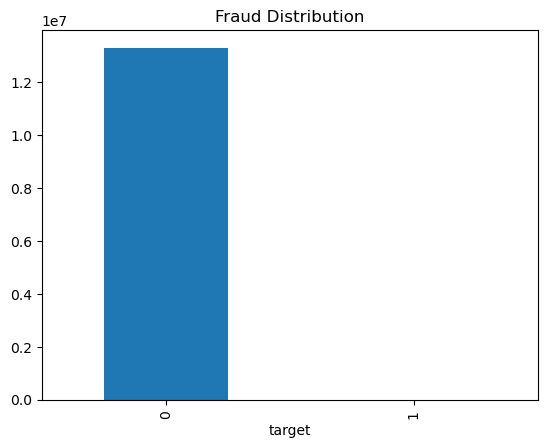

In [3]:
# Merge labels (exploratory only)
label_map = {'No': 0, 'Yes': 1}
fraud_numeric = fraud['target'].map(label_map)
transactions['target'] = fraud_numeric.reindex(transactions.index).fillna(0).astype(int)

transactions['target'].value_counts().plot(kind='bar')
plt.title("Fraud Distribution")
plt.show()


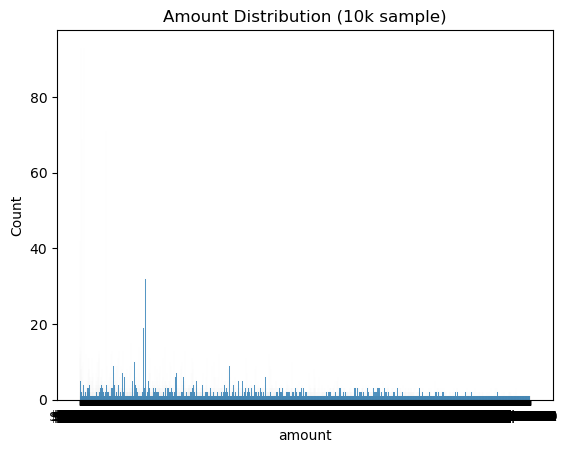

In [6]:
sample = transactions['amount'].sample(10000, random_state=42)

sns.histplot(sample, bins=50)
plt.title("Amount Distribution (10k sample)")
plt.show()


In [8]:
### 🔍 Key Observations

- Fraud cases are rare -> indicates strong imbalance.
- Transaction amounts are right-skewed.
- Some columns contain text, categorical values -> will require encoding.
- Date column can be expanded into time-based features.


SyntaxError: invalid syntax (3751321136.py, line 3)